# Inspecting the WikiText-2 Dataset

This notebook explores the WikiText-2 dataset used for perplexity evaluation in our benchmarks.

We download the **test split** of `Salesforce/wikitext` (wikitext-2-raw-v1) via `huggingface_hub`, the same way `bench_utils.load_wikitext2_tokens` does.

In [1]:
from huggingface_hub import hf_hub_download
import pyarrow.parquet as pq

path = hf_hub_download(
    repo_id="Salesforce/wikitext",
    repo_type="dataset",
    filename="wikitext-2-raw-v1/test-00000-of-00001.parquet",
)
table = pq.read_table(path)
print(f"Parquet file: {path}")
print(f"Schema: {table.schema}")
print(f"Total rows: {len(table)}")

/Users/bruski/.pyenv/versions/3.12.7/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Parquet file: /Users/bruski/.cache/huggingface/hub/datasets--Salesforce--wikitext/snapshots/b08601e04326c79dfdd32d625aee71d232d685c3/wikitext-2-raw-v1/test-00000-of-00001.parquet
Schema: text: string
-- schema metadata --
huggingface: '{"info": {"features": {"text": {"dtype": "string", "_type":' + 12
Total rows: 4358


## What is the "label" in WikiText-2?

WikiText-2 has **no explicit labels** — there's no sentiment column, no class, no score. It's just raw text.

The "label" is implicit: for language modeling, **the next token IS the label**. Given the sequence `The cat sat on the`, the label is `mat`. Every token in the corpus simultaneously serves as:
- **input** (context for predicting what comes after it)
- **label** (the target that the previous tokens should have predicted)

This is called **self-supervised learning** — the supervision signal comes from the structure of the data itself, not from human annotators.

### Downstream tasks WikiText-2 is used for

| Task | How WikiText-2 is used | What's measured |
|---|---|---|
| **Perplexity evaluation** (our benchmark) | Feed text through model, measure cross-entropy loss on next-token prediction | How well the model predicts natural language — lower = better |
| **Language model pre-training** | Train on the text directly with next-token prediction | Foundation capability of the model |
| **Quantization quality testing** | Compare perplexity before/after quantization | How much accuracy is lost from compression |
| **Architecture comparison** | Same text, different models | Which architecture models language better |

WikiText-2 is almost never used for training production models (it's too small at ~2M tokens). Its main role is as a **standardized evaluation benchmark** — a common yardstick so that different papers and tools can compare perplexity numbers on the same text.

In [2]:
# Demonstrate the implicit labeling: each token is both input and target
# Take the first body paragraph from the dataset
sample = next(r for r in table.column("text").to_pylist() if len(r.strip()) > 100)
print(f"Sample text: {sample[:200]}...\n")

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
ids = tokenizer.encode(sample)

# Show how the same sequence creates (input, label) pairs
print("Next-token prediction pairs (the self-supervised 'labels'):")
print("-" * 65)
print(f"{'Step':>4}  {'Input context (last 30 chars)':>35}  →  Label")
print("-" * 65)
for i in range(1, min(15, len(ids))):
    context = tokenizer.decode(ids[:i])
    label = tokenizer.decode([ids[i]])
    # Show just the tail of context so it fits
    ctx_display = context if len(context) <= 35 else "..." + context[-32:]
    print(f"{i:4d}  {ctx_display:>35}  →  {repr(label)}")

print(f"\n↑ Every position is a training example. {len(ids):,} tokens = {len(ids)-1:,} (input→label) pairs.")

Sample text:  Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons...

Next-token prediction pairs (the self-supervised 'labels'):
-----------------------------------------------------------------
Step        Input context (last 30 chars)  →  Label
-----------------------------------------------------------------
   1                               Robert  →  ' B'
   2                             Robert B  →  'oul'
   3                          Robert Boul  →  'ter'
   4                       Robert Boulter  →  ' is'
   5                    Robert Boulter is  →  ' an'
   6                 Robert Boulter is an  →  ' English'
   7         Robert Boulter is an English  →  ' film'
   8    Robert Boulter is an English film  →  ' ,'
   9  ...ert Boulter is an English film ,  →  ' television'
  10  ... is an English film , television  →  ' and'
  11

## Raw rows

Each row is a single line of text. Many rows are blank (paragraph separators) or section headers (prefixed with ` = `).

In [10]:
rows = table.column("text").to_pylist()

# Show the first 20 rows to get a feel for the structure
for i, row in enumerate(rows[:20]):
    tag = "BLANK" if not row.strip() else "TEXT"
    print(f"[{i:4d}] ({tag}) {row[:120]}")

[   0] (BLANK) 
[   1] (TEXT)  = Robert Boulter = 

[   2] (BLANK) 
[   3] (TEXT)  Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television s
[   4] (TEXT)  In 2006 , Boulter starred alongside Whishaw in the play Citizenship written by Mark Ravenhill . He appeared on a 2006 e
[   5] (BLANK) 
[   6] (TEXT)  = = Career = = 

[   7] (BLANK) 
[   8] (BLANK) 
[   9] (TEXT)  = = = 2000 – 2005 = = = 

[  10] (BLANK) 
[  11] (TEXT)  In 2000 Boulter had a guest @-@ starring role on the television series The Bill ; he portrayed " Scott Parry " in the e
[  12] (TEXT)  He had a recurring role in 2003 on two episodes of The Bill , as character " Connor Price " . In 2004 Boulter landed a 
[  13] (BLANK) 
[  14] (TEXT)  = = = 2006 – present = = = 

[  15] (BLANK) 
[  16] (TEXT)  In 2006 Boulter starred in the play Citizenship written by Mark Ravenhill . The play was part of a series which feature
[  17] (TEXT)  Boulter starred in two films 

## Basic statistics

In [4]:
blank_rows = [r for r in rows if not r.strip()]
non_blank = [r for r in rows if r.strip()]
header_rows = [r for r in non_blank if r.strip().startswith("=")]
body_rows = [r for r in non_blank if not r.strip().startswith("=")]

print(f"Total rows:    {len(rows)}")
print(f"Blank rows:    {len(blank_rows)}")
print(f"Non-blank:     {len(non_blank)}")
print(f"  Headers (=): {len(header_rows)}")
print(f"  Body text:   {len(body_rows)}")

# Character and word counts on the concatenated text (non-blank only)
full_text = "\n\n".join(r for r in rows if r.strip())
words = full_text.split()
print(f"\nConcatenated text length: {len(full_text):,} chars")
print(f"Word count:              {len(words):,}")

Total rows:    4358
Blank rows:    1467
Non-blank:     2891
  Headers (=): 708
  Body text:   2183

Concatenated text length: 1,291,402 chars
Word count:              241,211


## Row length distribution

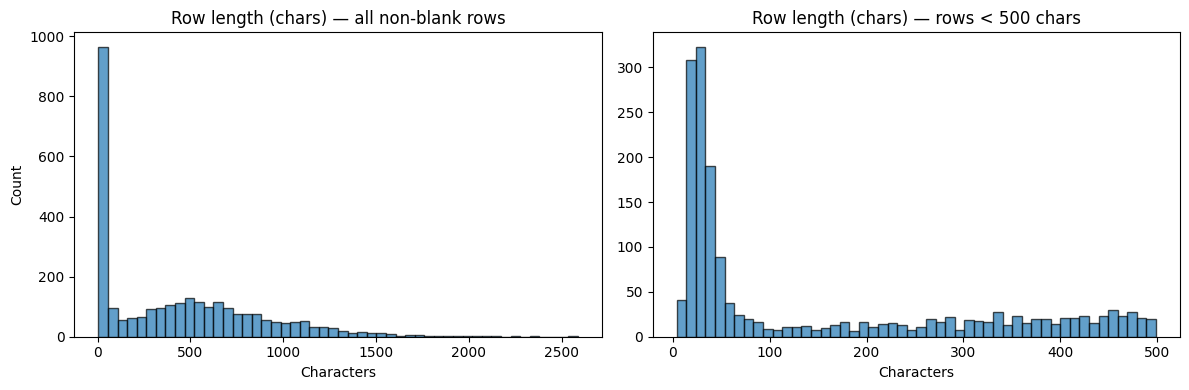

In [5]:
import matplotlib.pyplot as plt

lengths = [len(r) for r in non_blank]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lengths, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Row length (chars) — all non-blank rows")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

# Zoom in on rows < 500 chars to see the distribution better
axes[1].hist([l for l in lengths if l < 500], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_title("Row length (chars) — rows < 500 chars")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

## Sample section headers

WikiText-2 is sourced from Wikipedia "Good" and "Featured" articles. Headers give a sense of the topics covered.

In [6]:
# Top-level headers (single = on each side) are article titles
articles = [r.strip() for r in header_rows if r.strip().startswith("= ") and not r.strip().startswith("= =")]
sub_headers = [r.strip() for r in header_rows if r.strip().startswith("= =")]

print(f"Article-level headers: {len(articles)}")
print(f"Sub-section headers:   {len(sub_headers)}")
print("\n--- Sample articles ---")
for h in articles[:15]:
    print(f"  {h}")

Article-level headers: 64
Sub-section headers:   644

--- Sample articles ---
  = Robert Boulter =
  = Du Fu =
  = Kiss You ( One Direction song ) =
  = Ise @-@ class battleship =
  = Dick Rifenburg =
  = 1933 Treasure Coast hurricane =
  = Second Battle of Naktong Bulge =
  = Hed PE =
  = Ironclad warship =
  = Little Gidding ( poem ) =
  = The Portage to San Cristobal of A.H. =
  = Temnospondyli =
  = Osbert de Bayeux =
  = Dvorak technique =
  = New York State Route 31B =


## Tokenization preview

See how the text looks after tokenization with a small model's tokenizer (GPT-2 vocabulary, same family used by many LLMs).

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
token_ids = tokenizer.encode(full_text)

print(f"Total tokens (GPT-2 tokenizer): {len(token_ids):,}")
print(f"Chars per token (avg):          {len(full_text) / len(token_ids):.2f}")
print(f"Words per token (avg):          {len(words) / len(token_ids):.4f}")

# Show first 30 tokens decoded individually
print("\n--- First 30 tokens ---")
for i, tid in enumerate(token_ids[:30]):
    print(f"  [{i:3d}] id={tid:5d}  ->  {repr(tokenizer.decode([tid]))}")

Token indices sequence length is longer than the specified maximum sequence length for this model (286177 > 1024). Running this sequence through the model will result in indexing errors


Total tokens (GPT-2 tokenizer): 286,177
Chars per token (avg):          4.51
Words per token (avg):          0.8429

--- First 30 tokens ---
  [  0] id=  796  ->  ' ='
  [  1] id= 5199  ->  ' Robert'
  [  2] id=  347  ->  ' B'
  [  3] id= 2852  ->  'oul'
  [  4] id=  353  ->  'ter'
  [  5] id=  796  ->  ' ='
  [  6] id=  220  ->  ' '
  [  7] id=  628  ->  '\n\n'
  [  8] id=  198  ->  '\n'
  [  9] id= 5199  ->  ' Robert'
  [ 10] id=  347  ->  ' B'
  [ 11] id= 2852  ->  'oul'
  [ 12] id=  353  ->  'ter'
  [ 13] id=  318  ->  ' is'
  [ 14] id=  281  ->  ' an'
  [ 15] id= 3594  ->  ' English'
  [ 16] id= 2646  ->  ' film'
  [ 17] id=  837  ->  ' ,'
  [ 18] id= 5581  ->  ' television'
  [ 19] id=  290  ->  ' and'
  [ 20] id=21421  ->  ' theatre'
  [ 21] id= 8674  ->  ' actor'
  [ 22] id=  764  ->  ' .'
  [ 23] id=  679  ->  ' He'
  [ 24] id=  550  ->  ' had'
  [ 25] id=  257  ->  ' a'
  [ 26] id= 8319  ->  ' guest'
  [ 27] id= 2488  ->  ' @'
  [ 28] id=   12  ->  '-'
  [ 29] id=   31  ->  '

## Sliding-window perplexity context

Our benchmark (`bench_utils.compute_perplexity`) uses a sliding window with `max_length=2048` and `stride=512`. Let's see how many windows that creates.

In [8]:
seq_len = len(token_ids)
max_length = 2048
stride = 512

n_windows = 0
for begin in range(0, seq_len, stride):
    end = min(begin + max_length, seq_len)
    n_windows += 1
    if end == seq_len:
        break

print(f"Sequence length:  {seq_len:,} tokens")
print(f"Window size:      {max_length}")
print(f"Stride:           {stride}")
print(f"Number of windows: {n_windows}")
print(f"\nThis is what the model processes during perplexity evaluation.")

Sequence length:  286,177 tokens
Window size:      2048
Stride:           512
Number of windows: 556

This is what the model processes during perplexity evaluation.


## How does the model actually "predict" tokens?

The model doesn't output a single guess — it outputs a **probability distribution over every token in the vocabulary** at each position. The loss function (cross-entropy) then checks: how much probability did you assign to the token that actually came next?

```
Input:  "The cat sat on the"

Model output at this position (50,257 probabilities):
   "mat"    → 0.12   ← actual next token
   "floor"  → 0.08
   "ground" → 0.06
   "table"  → 0.04
   ...
   "banana" → 0.0001

Cross-entropy loss = -log(0.12) = 2.12
```

**Perplexity** is just `exp(average cross-entropy loss)` across all positions. If the average loss is 2.7, perplexity = e^2.7 ≈ 15 — meaning the model is, on average, as uncertain as picking uniformly among 15 options.

Let's see this in action with GPT-2 on actual WikiText-2 text:

In [9]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")
model.eval()

# Take a short snippet from WikiText-2
snippet = next(r for r in table.column("text").to_pylist() if len(r.strip()) > 80)
input_ids = tokenizer.encode(snippet, return_tensors="pt")

# Run the model — get logits (raw scores) for every position
with torch.no_grad():
    logits = model(input_ids).logits  # shape: [1, seq_len, vocab_size]

# For each position, show the model's top predictions vs. the actual next token
print(f"Text: {snippet[:120]}...\n")
print(f"Vocab size: {logits.shape[-1]:,} (model outputs this many probabilities per position)\n")
print(f"{'Pos':>3}  {'Actual next token':>20}  {'P(actual)':>9}  {'Top-1 prediction':>20}  {'P(top-1)':>8}")
print("-" * 90)

seq_len = input_ids.shape[1]
for i in range(min(20, seq_len - 1)):
    probs = F.softmax(logits[0, i], dim=-1)

    actual_id = input_ids[0, i + 1].item()
    actual_token = repr(tokenizer.decode([actual_id]))
    actual_prob = probs[actual_id].item()

    top_id = probs.argmax().item()
    top_token = repr(tokenizer.decode([top_id]))
    top_prob = probs[top_id].item()

    match = "<<" if top_id == actual_id else ""
    print(f"{i:3d}  {actual_token:>20}  {actual_prob:9.4f}  {top_token:>20}  {top_prob:8.4f}  {match}")

print("\n'<<' = model's top prediction matched the actual token")
print("Notice: even when the model is 'wrong', it often assigns reasonable probability to the actual token.")

W0416 11:20:52.581000 41661 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12212.17it/s]


Text:  Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television s...

Vocab size: 50,257 (model outputs this many probabilities per position)

Pos     Actual next token  P(actual)      Top-1 prediction  P(top-1)
------------------------------------------------------------------------------------------
  0                  ' B'     0.0026                   ','    0.0554  
  1                 'oul'     0.0024                   '.'    0.3577  
  2                 'ter'     0.0258                 'ton'    0.4338  
  3                 ' is'     0.0297                   ','    0.3740  
  4                 ' an'     0.0577                  ' a'    0.2179  
  5            ' English'     0.0073          ' associate'    0.0801  
  6               ' film'     0.0014             ' writer'    0.1556  
  7                  ' ,'     0.0000             ' critic'    0.4544  
  8         ' television'     0.0245                ' and'    0.0674